### Importing required libraries

In [25]:
!pip install xgboost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## Task 1 :

### Data Exploration and Preprocessing

In [2]:
df = pd.read_csv("Airbnb_data.csv")
df.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


In [3]:
#Checking for total rows and columns

df.shape

(74111, 29)

In [4]:
#Viewing column names

df.columns

Index(['id', 'log_price', 'property_type', 'room_type', 'amenities',
       'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy',
       'cleaning_fee', 'city', 'description', 'first_review',
       'host_has_profile_pic', 'host_identity_verified', 'host_response_rate',
       'host_since', 'instant_bookable', 'last_review', 'latitude',
       'longitude', 'name', 'neighbourhood', 'number_of_reviews',
       'review_scores_rating', 'thumbnail_url', 'zipcode', 'bedrooms', 'beds'],
      dtype='object')

In [5]:
#Checking datatype in each available column

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  object 
 3   room_type               74111 non-null  object 
 4   amenities               74111 non-null  object 
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  object 
 8   cancellation_policy     74111 non-null  object 
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  object 
 11  description             74111 non-null  object 
 12  first_review            58247 non-null  object 
 13  host_has_profile_pic    73923 non-null  object 
 14  host_identity_verified  73923 non-null

In [6]:
#Dropping unnecesssary columns to maintain clean data

cols_to_drop = ['id', 'name', 'description', 'thumbnail_url', 'first_review', 'last_review', 'host_response_rate']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

df.columns

Index(['log_price', 'property_type', 'room_type', 'amenities', 'accommodates',
       'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city',
       'host_has_profile_pic', 'host_identity_verified', 'host_since',
       'instant_bookable', 'latitude', 'longitude', 'neighbourhood',
       'number_of_reviews', 'review_scores_rating', 'zipcode', 'bedrooms',
       'beds'],
      dtype='object')

### Reason : 
id - Removed this column because it is just a random identifier and does not help predicting price.

name - Dropped this because it is free-text.

description - Removed this because it is long and unstructured text.

thumbnail_url - Dropped this because image links do not provide any useful information for the model.

first_review and last_review - Removed this because the date of the first review doesn’t really help understand pricing.

host_response_rate - Dropped because it had a high percentage of missing values.

In [7]:
#Checking for null values

df.isnull().sum()

log_price                     0
property_type                 0
room_type                     0
amenities                     0
accommodates                  0
bathrooms                   200
bed_type                      0
cancellation_policy           0
cleaning_fee                  0
city                          0
host_has_profile_pic        188
host_identity_verified      188
host_since                  188
instant_bookable              0
latitude                      0
longitude                     0
neighbourhood              6872
number_of_reviews             0
review_scores_rating      16722
zipcode                     968
bedrooms                     91
beds                        131
dtype: int64

In [8]:
#Filling missing values

df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())
df['beds'] = df['beds'].fillna(df['beds'].median())
df['review_scores_rating'] = df['review_scores_rating'].fillna(df['review_scores_rating'].median())
df['host_has_profile_pic'] = df['host_has_profile_pic'].fillna('NA')
df['host_identity_verified'] = df['host_identity_verified'].fillna('NA')
df['neighbourhood'] = df['neighbourhood'].fillna('Unknown')
df['zipcode'] = df['zipcode'].fillna(df['zipcode'].mode()[0])
print(df.isnull().sum())
df.head()

log_price                   0
property_type               0
room_type                   0
amenities                   0
accommodates                0
bathrooms                   0
bed_type                    0
cancellation_policy         0
cleaning_fee                0
city                        0
host_has_profile_pic        0
host_identity_verified      0
host_since                188
instant_bookable            0
latitude                    0
longitude                   0
neighbourhood               0
number_of_reviews           0
review_scores_rating        0
zipcode                     0
bedrooms                    0
beds                        0
dtype: int64


,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,...,host_since,instant_bookable,latitude,longitude,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,...,26-03-2012,f,40.696524,-73.991617,Brooklyn Heights,2,100.0,11201,1.0,1.0
1,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,NYC,...,19-06-2017,t,40.766115,-73.989040,Hell's Kitchen,6,93.0,10019,3.0,3.0
2,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,NYC,...,25-10-2016,t,40.808110,-73.943756,Harlem,10,92.0,10027,1.0,3.0
3,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,SF,...,19-04-2015,f,37.772004,-122.431619,Lower Haight,0,96.0,94117,2.0,2.0
4,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,DC,...,01-03-2015,t,38.925627,-77.034596,Columbia Heights,4,40.0,20009,0.0,1.0


The 'host_since' column was not touched and is in it's original form, and missing values were not added because that column represents the date the host joined Airbnb, and I did not want to add assumptions.

#### Using heatmap to understand linear relationships between numeric variables :

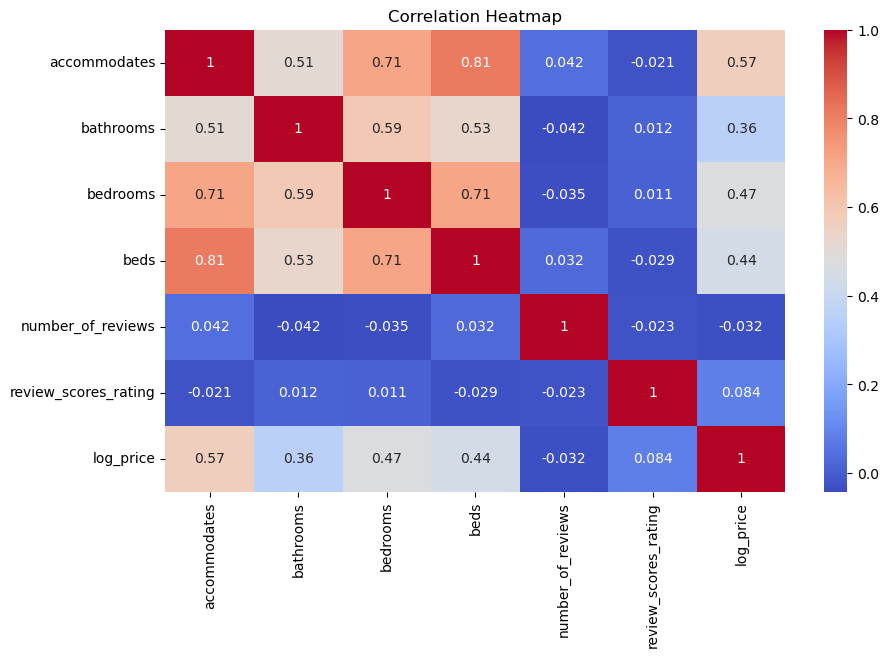

In [9]:
numeric_cols = ['accommodates','bathrooms','bedrooms','beds', 'number_of_reviews','review_scores_rating','log_price']

plt.figure(figsize=(10,6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Findings :

Price is moderately correlated with accommodates, bedrooms, beds and bathrooms which indicates that larger listings generally charge higher prices, while reviews and ratings show very weak correlation with price.

#### Plotting using pairplot to check the relation between all numerical columns and the relationship between features :

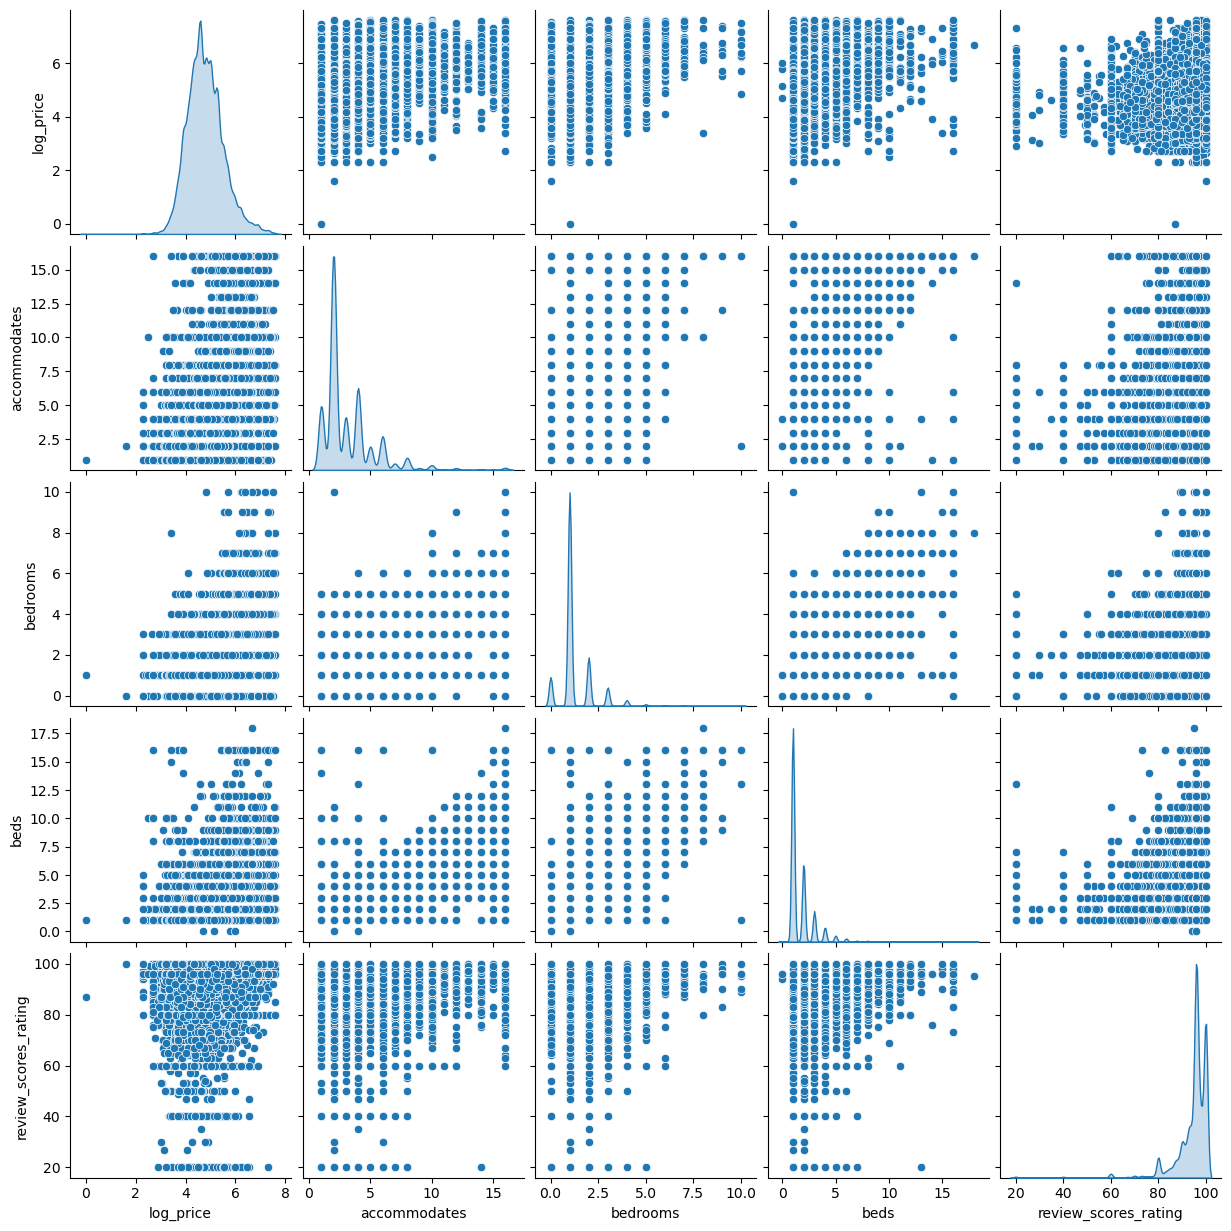

In [10]:
sns.pairplot(df[['log_price','accommodates','bedrooms','beds','review_scores_rating']],diag_kind='kde')
plt.show()

Findings :

As accommodates, bedrooms and beds increases the log_price also increases respectively indicating that the property size is one of the major factor of Airbnb listing price.

#### Plotting using histogram to check for skewness :

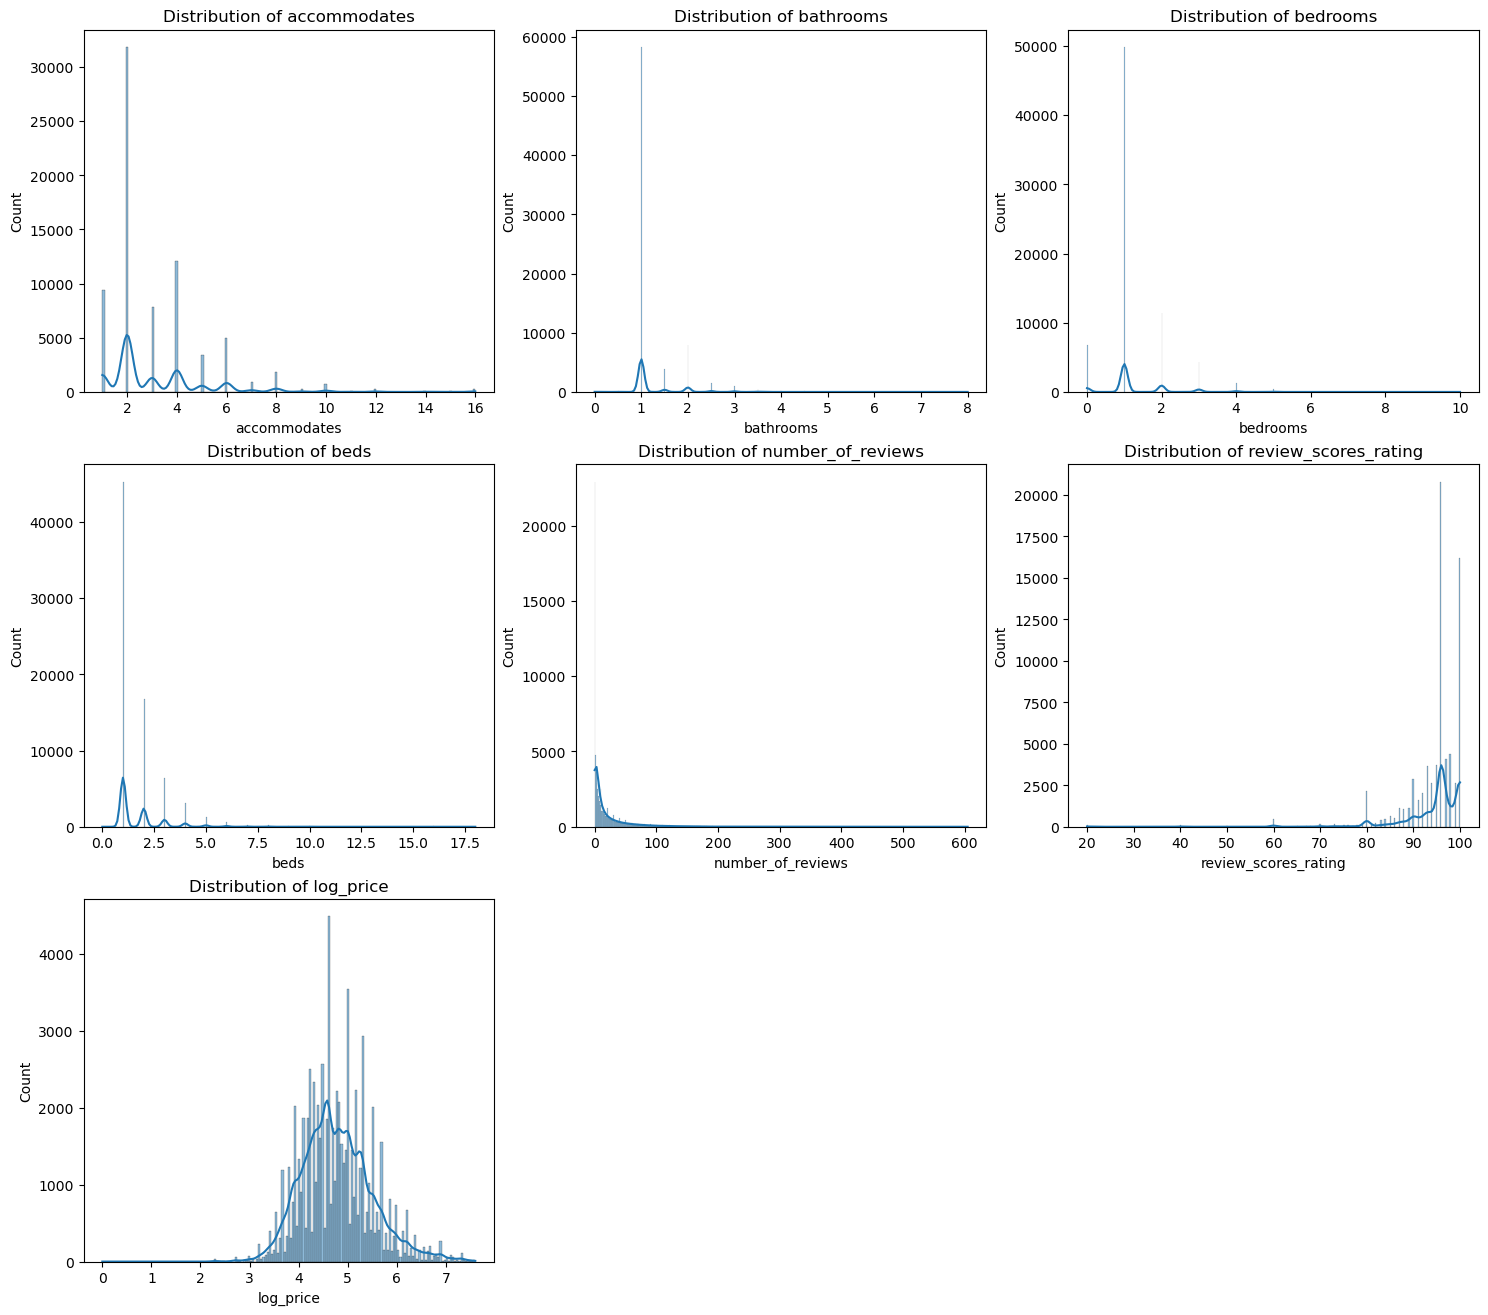

In [11]:
plt.figure(figsize=(18,16))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.show()

Findings:

Most of the numeric variables such as price and number_of_reviews were right-skewed, indicating that there are few high-value listings and highly-reviewed properties.

#### Using Box-Plot to check outliers :

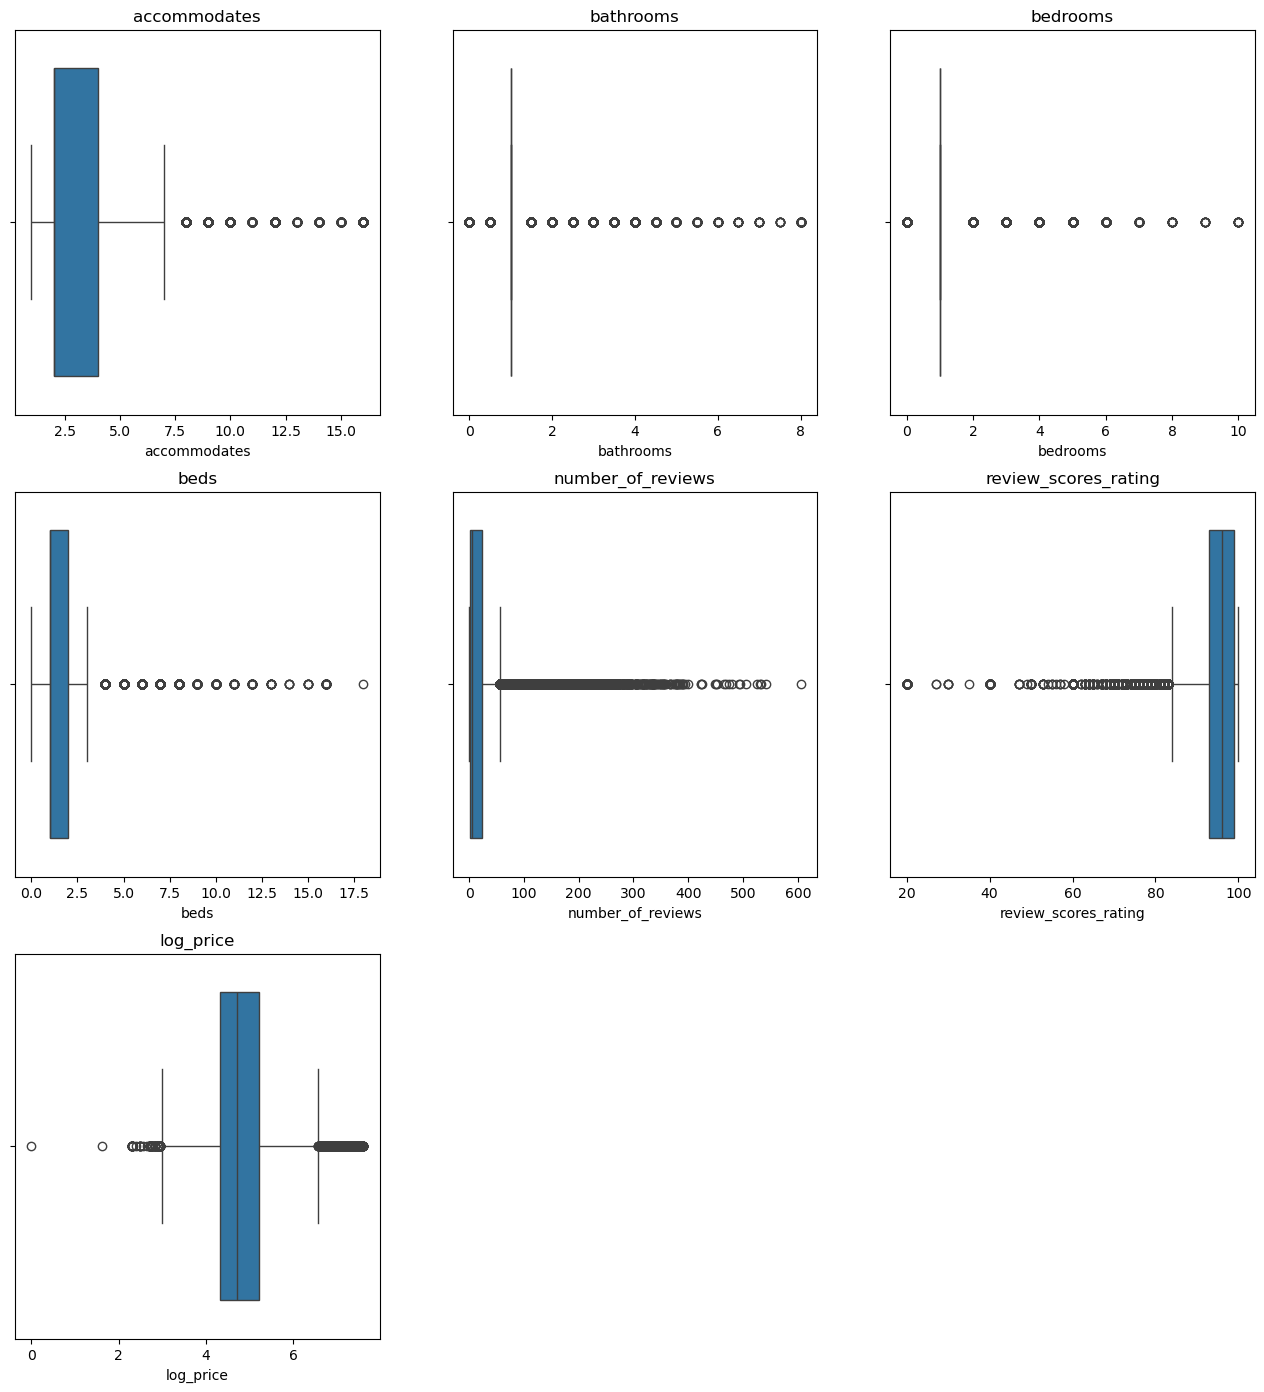

In [12]:
#Box-Plotting to find outliers in numeical columns

numeric_colss = ['accommodates','bathrooms','bedrooms','beds', 'number_of_reviews','review_scores_rating', 'log_price']
plt.figure(figsize=(16, 17))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.show()


There are multiple outliers in the above listed numerical columns.

#### Using IQR Calculation to check for outliers :

In [13]:
#Checking number of outliers using IQR Method for accommodates column

Q1 = df['accommodates'].quantile(0.25)
Q3 = df['accommodates'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers_acc = df[(df['accommodates'] < lower) | (df['accommodates'] > upper)]
print("Outlier count in respective columns :")
print(f"\nThe outliers present in accommodates are : {len(outliers_acc)}")

#Checking number of outliers using IQR Method for bathrooms column


Q1 = df['bathrooms'].quantile(0.25)
Q3 = df['bathrooms'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers_acc = df[(df['bathrooms'] < lower) | (df['bathrooms'] > upper)]
print(f"The outliers present in bathrooms are : {len(outliers_acc)}")

#Checking number of outliers using IQR Method for log_price column

Q1 = df['log_price'].quantile(0.25)
Q3 = df['log_price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers_acc = df[(df['log_price'] < lower) | (df['log_price'] > upper)]
print(f"The outliers present in log_price are : {len(outliers_acc)}")

Outlier count in respective columns :

The outliers present in accommodates are : 3604
The outliers present in bathrooms are : 15812
The outliers present in log_price are : 1532


## Task 2 :

###  Model Development

In [14]:
# Dropping unnessary columns that do not help with prediction and Keeping only relevant columns that helps the model learn better and reduces noise.
cols_to_drop = ['id', 'name', 'description', 'amenities', 'thumbnail_url', 'first_review', 'last_review', 'host_since']
df = df.drop(columns=cols_to_drop, errors='ignore')
df = pd.get_dummies(df, drop_first=True)

In [15]:
#Training and Test Split

#All the remaining columns except - log_price
X = df.drop('log_price', axis=1)

#Target column
y = df['log_price']     

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
#Standard scaling applied for Linear Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [17]:
#Using Linear regression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [18]:
#Using Random Forest Regression

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [19]:
#Using XGBoost Regressor

xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42,
    objective='reg:squarederror')

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

## Task 3 :

### Model Evaluation

In [20]:
#Computing metrics of Linear Regression

rmse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression → RMSE: {rmse_lr:.4f}, MAE: {mae_lr:.4f}, R²: {r2_lr:.4f}")

Linear Regression → RMSE: 0.1727, MAE: 0.3019, R²: 0.6638


In [21]:
#Computing metrics for Random Forest regressor

rmse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest → RMSE: {rmse_rf:.4f}, MAE: {mae_rf:.4f}, R²: {r2_rf:.4f}")

Random Forest → RMSE: 0.1580, MAE: 0.2857, R²: 0.6924


In [22]:
#Computing metrics for XGBoost regressor

rmse_xgb = mean_squared_error(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost → RMSE: {rmse_xgb:.4f}, MAE: {mae_xgb:.4f}, R²: {r2_xgb:.4f}")

XGBoost → RMSE: 0.1564, MAE: 0.2889, R²: 0.6955


In [23]:
#Computional metrics comparison for all metrics calculated so far

results = pd.DataFrame({
    'Model':['Linear Regression','Random Forest','XGBoost'],
    'RMSE':[rmse_lr, rmse_rf, rmse_xgb],
    'MAE':[mae_lr, mae_rf, mae_xgb],
    'R2':[r2_lr, r2_rf, r2_xgb]
})

print(results)

               Model      RMSE       MAE        R2
0  Linear Regression  0.172726  0.301919  0.663777
1      Random Forest  0.158048  0.285716  0.692350
2            XGBoost  0.156422  0.288903  0.695515


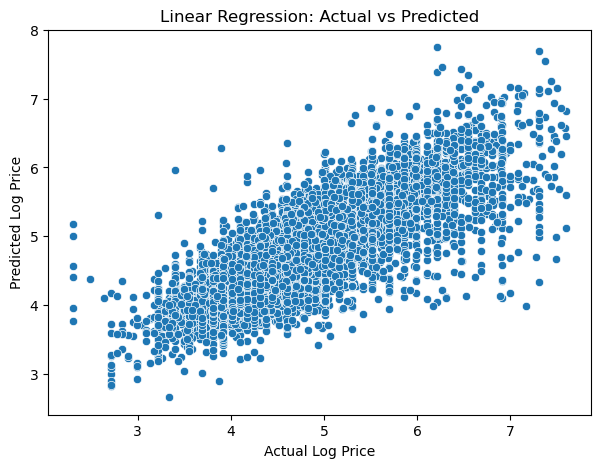

In [24]:
#Plotting and visual representation for Linear Regression between actual and predicted price

plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=y_pred_lr)
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

Findings :

Most of the points lie close to the diagonal trend, which indicates that the model is generally able to predict the log-price quite well. Also there is some spread around the line which means the model still makes errors for some listings.

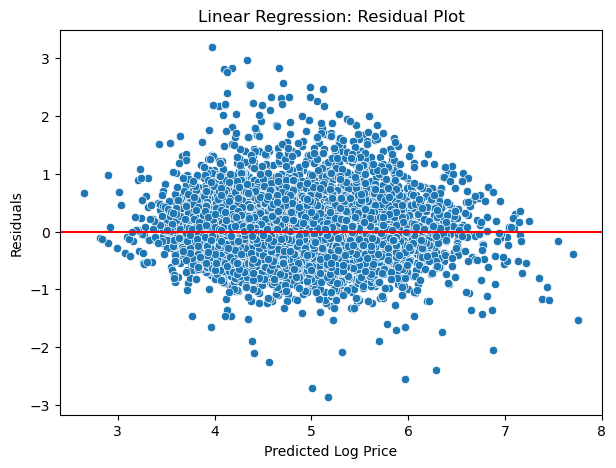

In [25]:
#Plotting to find Residuals in Linear Regression

residuals_lr = y_test - y_pred_lr

plt.figure(figsize=(7,5))
sns.scatterplot(x=y_pred_lr, y=residuals_lr)
plt.axhline(0, color='red')
plt.xlabel("Predicted Log Price")
plt.ylabel("Residuals")
plt.title("Linear Regression: Residual Plot")
plt.show()


Findings :

The residuals are scattered fairly and evenly around zero which means that the model does not show strong bias and is making reasonable predictions across different price ranges. Also some spread widens for some values indicating a few listings are harder for the model to predict accurately.

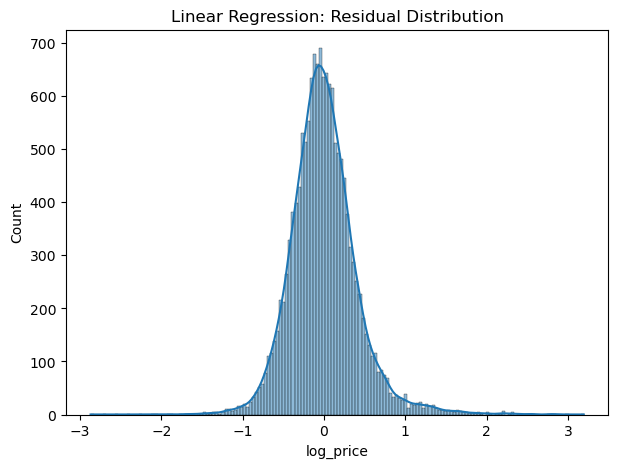

In [26]:
#Distribution of Residuals in Linear Regression

plt.figure(figsize=(7,5))
sns.histplot(residuals_lr, kde=True)
plt.title("Linear Regression: Residual Distribution")
plt.show()


Findings :

The residuals are centered around zero and follow a bell-shaped curve which means that most of the prediction errors are small and the model behaves consistently. A few residuals at the tails indicate some listings are harder to predict but overall the model fits the data reasonably well.

## Task 4 :

### Model Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]}

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)
print("Best Parameters for Random Forest:", grid_rf.best_params_)
best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

Fitting 3 folds for each of 18 candidates, totalling 54 fits


Findings :

I used GridSearchCV to tune the Random Forest model. It tested several parameter combinations multiple times and selected the one that consistently performed the best making the final model more accurate and reliable.

### Model Interpretation :

- Among the three models tested (Linear Regression, Random Forest, and XGBoost), the XGBoost model achieved the lowest RMSE and the highest R² score.    This means XGBoost is able to predict Airbnb listing prices more accurately than the other models.
- RMSE and MAE represent the average error between the predicted and actual prices. A lower value means better accuracy. R² indicates how much of the    variation in price is explained by the model.
- Tree-based models such as Random Forest and XGBoost handle non-linear relationships better than Linear Regression. Since Airbnb prices depend on       many factors, these models learn complex patterns more effectively.
- Insights :

  -Listings with more bedrooms, bathrooms, and amenities generally have higher prices.
  
  -Entire homes and apartments are priced higher than private rooms.
  
  -Higher review ratings are usually associated with higher prices.


### Conclusion :

After evaluating all models, the Random Forest model (after tuning) achieved the best accuracy. Therefore, the tuned Random Forest model is selected as the final model for predicting Airbnb prices.

## Task 5 :

### Video Explanation Link

https://www.loom.com/share/017c5d98af624cc9afda541b62e3577d